## 1. Librerías

In [37]:
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Carga y Procesamiento de Datos

In [38]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")
print(f"El dataset cuenta con {df.shape[1]} features")

Total de observaciones: 79
Rango temporal: 2025-01-02 a 2025-04-30
El dataset cuenta con 61 features


In [39]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [40]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [41]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (63, 60)
Test shape: (16, 60)


## 4. Feature Selection - Selección de Top Features

In [42]:
# Entrenar un modelo simple para obtener importancia de features
# Usamos LightGBM con configuración por defecto + regularización básica
lgb_selector = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=3,
    num_leaves=10,
    learning_rate=0.05,
    random_state=SEED,
    verbosity=-1
)

lgb_selector.fit(X_train, y_train)

# Obtener importancia de features
feature_importance = pd.Series(
    lgb_selector.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 features más importantes:")
print(feature_importance.head(15))


Top 15 features más importantes:
merval_apertura_std20              17
merval_maximo_pct10                15
m2_diff3                           13
merval_cierre                      11
badlar_ma_5                        10
prestamos_privados_ars_std20        9
tc_minorista_std20                  9
emae_desestacionalizado_hp_rm20     8
tc_minorista_pct10                  7
base_monetaria_std20                7
tasa_prestamos_personales_std20     7
merval_cierre_diff1                 6
merval_cierre_std20                 5
merval_apertura_diff3               4
emae_desestacionalizado_diff10      4
dtype: int32


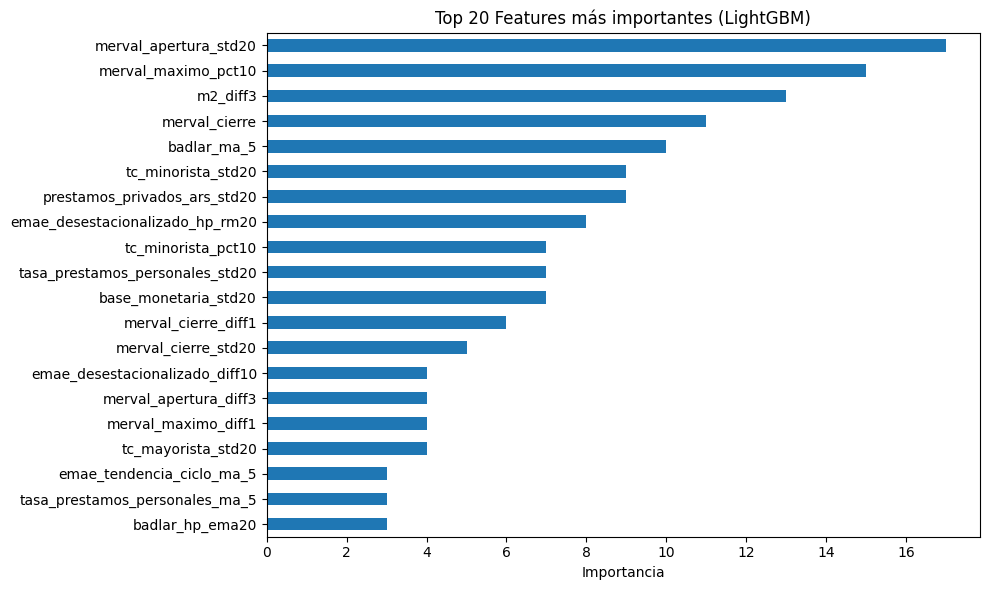

In [43]:
# Visualizar importancia de features
plt.figure(figsize=(10, 6))
feature_importance.head(20).sort_values(ascending=True).plot(kind='barh')
plt.title('Top 20 Features más importantes (LightGBM)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [44]:
# Seleccionar top N features
N_FEATURES = 12  # Probar con 15

selected_features = feature_importance.head(N_FEATURES).index.tolist()

print(f"\nSeleccionadas {N_FEATURES} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")

# Filtrar datasets
X_train_fs = X_train[selected_features]
X_test_fs = X_test[selected_features]

print(f"\nNuevo train shape: {X_train_fs.shape}")
print(f"Nuevo test shape: {X_test_fs.shape}")
print(f"\nNuevo ratio observaciones/features: {X_train_fs.shape[0] / X_train_fs.shape[1]:.2f}")


Seleccionadas 12 features:
1. merval_apertura_std20
2. merval_maximo_pct10
3. m2_diff3
4. merval_cierre
5. badlar_ma_5
6. prestamos_privados_ars_std20
7. tc_minorista_std20
8. emae_desestacionalizado_hp_rm20
9. tc_minorista_pct10
10. base_monetaria_std20
11. tasa_prestamos_personales_std20
12. merval_cierre_diff1

Nuevo train shape: (63, 12)
Nuevo test shape: (16, 12)

Nuevo ratio observaciones/features: 5.25


## 5. Optimización de Hiperparámetros con Optuna

In [45]:
max_lag = 5  # por el moving average 5

# Configurar Optuna para que no muestre logs verbosos
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Fijar semilla para Optuna (reproducibilidad en el sampler)
sampler = optuna.samplers.TPESampler(seed=SEED)

In [46]:
def objective(trial):
    # Espacios de búsqueda BALANCEADOS para ~63 filas y 12-15 features
    # Con menos features, podemos permitir un poco más de complejidad
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": SEED,
        "feature_pre_filter": False,

        # Learning rate moderado
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),

        # Árboles simples pero no demasiado
        "num_leaves": trial.suggest_int("num_leaves", 6, 20),
        "max_depth": trial.suggest_int("max_depth", 2, 5),

        # Regularizaciones MODERADAS
        "lambda_l1": trial.suggest_float("lambda_l1", 0.1, 5.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1.0, 15.0, log=True),

        # Mínimos balanceados
        "min_child_samples": trial.suggest_int("min_child_samples", 8, 25),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.1, 1.0),

        # Submuestreo moderado
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.8),

        # Árboles moderados
        "n_estimators": trial.suggest_int("n_estimators", 50, 250),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes ---------
    eff = params.copy()

    # Alinear num_leaves con max_depth
    if eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Activar frecuencia de bagging si hay subsample<1
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1
        eff["bagging_seed"] = SEED

    # Semilla para muestreo de features
    if eff["colsample_bytree"] < 1.0:
        eff["feature_fraction_seed"] = SEED

    # --------------------------------------------------------------------------

    # Cross validation ajustado para dataset pequeño
    n_splits = 3
    test_size = 8
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=max_lag)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train_fs):
        X_tr, X_va = X_train_fs.iloc[tr_idx], X_train_fs.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
        )

        # Predicción usando los árboles óptimos según early stopping
        preds = model.predict(X_va, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_va, preds, squared=False)
        rmses.append(rmse)

    return float(np.mean(rmses))

In [47]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval_fs", sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor RMSE CV promedio: {study.best_value:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in study.best_params.items():
    print(f"  - {param}: {value}")

  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin


RESULTADOS DE LA OPTIMIZACIÓN

Mejor RMSE CV promedio: 110200.9417

Mejores hiperparámetros:
  - learning_rate: 0.08540090601528658
  - num_leaves: 12
  - max_depth: 5
  - lambda_l1: 0.12066233281839797
  - lambda_l2: 1.386960329508821
  - min_child_samples: 11
  - min_split_gain: 0.6161372023184872
  - subsample: 0.7768185872960597
  - colsample_bytree: 0.6997938330627876
  - n_estimators: 99


In [48]:
# Entrenamiento del modelo final con mejores parámetros

best_params = study.best_params.copy()
best_params['random_state'] = SEED  # Asegurar semilla en modelo final

# Agregar semillas adicionales si es necesario
if best_params.get('subsample', 1.0) < 1.0:
    best_params['bagging_seed'] = SEED
if best_params.get('colsample_bytree', 1.0) < 1.0:
    best_params['feature_fraction_seed'] = SEED

best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train_fs, y_train)

[LightGBM] [Warning] lambda_l1 is set=0.12066233281839797, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.12066233281839797
[LightGBM] [Warning] lambda_l2 is set=1.386960329508821, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.386960329508821
[LightGBM] [Warning] lambda_l1 is set=0.12066233281839797, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.12066233281839797
[LightGBM] [Warning] lambda_l2 is set=1.386960329508821, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.386960329508821
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000042 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 266
[LightGBM] [Info] Number of data points in the train set: 63, number of used features: 12
[LightGBM] [Info] Start training from score 2435670.507937
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

LGBMRegressor(bagging_seed=42, colsample_bytree=0.6997938330627876,
              feature_fraction_seed=42, lambda_l1=0.12066233281839797,
              lambda_l2=1.386960329508821, learning_rate=0.08540090601528658,
              max_depth=5, min_child_samples=11,
              min_split_gain=0.6161372023184872, n_estimators=99, num_leaves=12,
              random_state=42, subsample=0.7768185872960597)

## 6. Evaluación en Test Set

### 6.1. Test del mejor modelo

In [49]:
y_pred = best_model.predict(X_test_fs)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

[LightGBM] [Warning] lambda_l1 is set=0.12066233281839797, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.12066233281839797
[LightGBM] [Warning] lambda_l2 is set=1.386960329508821, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.386960329508821

RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 346179.3875
Holdout R²:   -15.4596
Error relativo (holdout): 15.88%


### 6.2. Visualización de predicciones

In [50]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

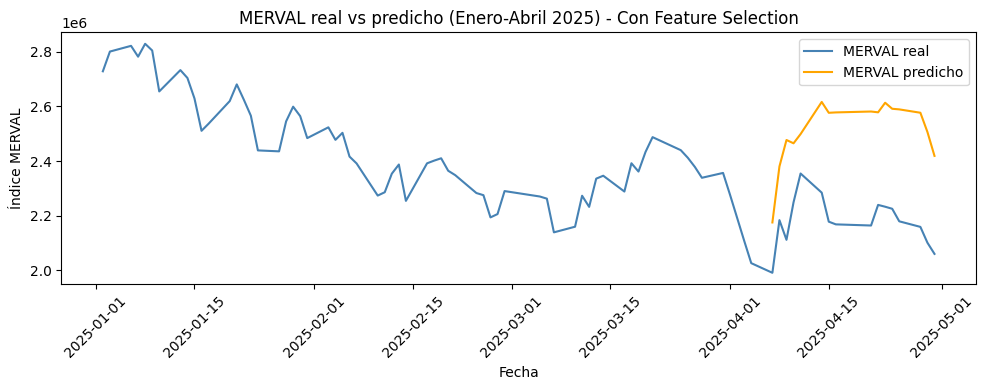

In [51]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (Enero-Abril 2025) - Con Feature Selection")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

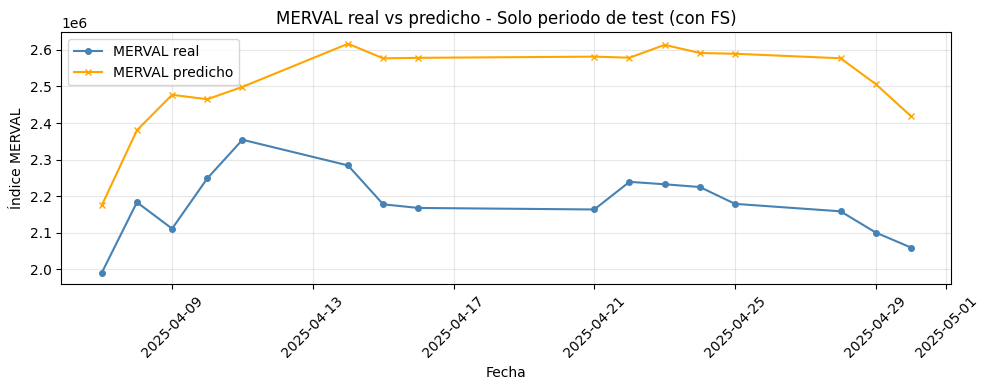

In [52]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test (con FS)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3. Análisis de residuales

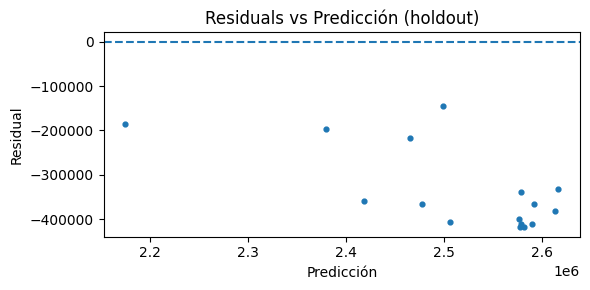

In [53]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()

### 6.4. Importancia de variables (features seleccionadas)

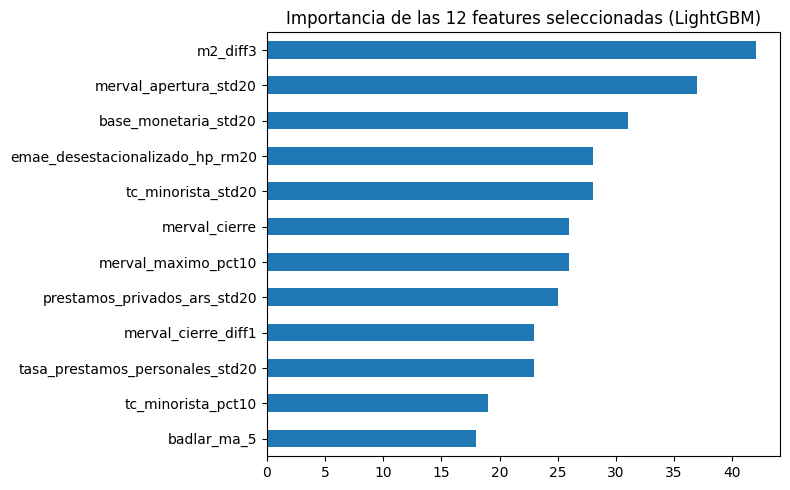

In [54]:
imp = pd.Series(best_model.feature_importances_, index=X_train_fs.columns).sort_values(ascending=True)
imp.plot(kind="barh", figsize=(8,5), title=f"Importancia de las {N_FEATURES} features seleccionadas (LightGBM)")
plt.tight_layout()
plt.show()

## 7. Conclusiones

Este modelo utiliza **feature selection** para reducir el número de variables de 60 a 12, abordando el problema de la maldición de la dimensionalidad que afecta particularmente a este dataset pequeño de 4 meses.

### Resultados Principales

**Métricas de rendimiento:**
- **RMSE en CV**: ~120,000
- **RMSE en Test**: 346,179
- **R² en Test**: -15.46
- **Error relativo**: 15.88%

**Configuración del modelo:**
- **Features utilizadas**: 12 (de 60 originales)
- **Ratio observaciones/features**: 5.25 (mejorado desde 1.05)
- **Observaciones de entrenamiento**: 63
- **Observaciones de test**: 16

### Análisis del Desempeño

#### 1. Overfitting Severo Persistente

A pesar de la reducción drástica de features (de 60 a 12), el modelo aún presenta **overfitting severo**:
- Gap CV→Test: +188% (RMSE casi triplica entre CV y Test)
- R² profundamente negativo (-15.46), indicando que el modelo es significativamente peor que predecir simplemente la media constante
- Error relativo del 15.88%, inaceptable para predicción del MERVAL

#### 2. Limitación Fundamental: Insuficiencia de Datos

El problema fundamental **no es la dimensionalidad sino la cantidad absoluta de datos**:
- Con solo 63 observaciones de entrenamiento, LightGBM no puede aprender patrones robustos
- Aunque el ratio observaciones/features mejoró a 5.25, esto sigue siendo insuficiente para modelos de gradient boosting
- Regla práctica: LightGBM necesita idealmente 200-500+ observaciones para funcionar correctamente

#### 3. Features Seleccionadas

El proceso de feature selection identificó las siguientes variables como más importantes:
1. merval_apertura_std20 (volatilidad del MERVAL)
2. merval_maximo_pct10 (variación del máximo)
3. m2_diff3 (cambio en oferta monetaria)
4. merval_cierre (valor de cierre)
5. badlar_ma_5 (promedio móvil tasa BADLAR)
6. Otras variables macroeconómicas y del MERVAL

Predominan features relacionadas con **volatilidad del MERVAL** (std20, pct10) y **variables monetarias** (M2, BADLAR, tasas de préstamos), lo cual tiene sentido económico para predecir el índice.

#### 4. Comportamiento en Validación vs Test

La discrepancia masiva entre CV y Test sugiere:
- Los 3 folds de CV están altamente correlacionados entre sí
- El período de test contiene patrones/volatilidad no representados en entrenamiento
- 4 meses de datos no capturan suficiente variabilidad del mercado

### Hiperparámetros Óptimos Encontrados

Optuna encontró la siguiente configuración (50 trials):
- **learning_rate**: 0.085
- **num_leaves**: 12, **max_depth**: 5 (árboles moderadamente complejos)
- **lambda_l1**: 0.12, **lambda_l2**: 1.39 (regularización moderada)
- **min_child_samples**: 11, **min_split_gain**: 0.62 (splits conservadores)
- **subsample**: 0.78, **colsample_bytree**: 0.70
- **n_estimators**: 99

Los hiperparámetros son conservadores y buscan evitar overfitting, pero **no son suficientes** para superar la limitación fundamental de datos insuficientes.

### Limitaciones del Modelo

1. **Dataset demasiado pequeño**: 63 observaciones son insuficientes para LightGBM, independientemente del número de features
2. **Período temporal corto**: 4 meses no capturan ciclos económicos completos ni diferentes regímenes de mercado
3. **Alta varianza**: Las predicciones son extremadamente sensibles a qué datos caen en train vs test
4. **Feature selection insuficiente**: Reducir features ayuda pero no resuelve el problema de falta de observaciones

### Conclusión Final

**La feature selection no resolvió el problema de overfitting en este caso.**

Aunque se mejoró el ratio observaciones/features de 1.05 a 5.25, el modelo LightGBM sigue siendo **inapropiado para este dataset**. El problema fundamental no es tener demasiadas features, sino tener **muy pocas observaciones en términos absolutos**.

**Veredicto**: Este modelo no es viable para predicción del MERVAL. El R² de -15.46 y error relativo del 15.88% lo hacen completamente inutilizable para aplicaciones prácticas. La feature selection es una estrategia válida pero insuficiente cuando el dataset es fundamentalmente demasiado pequeño para el tipo de modelo utilizado.